In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn import svm

In [2]:
df = pd.read_csv('D:\Private\Python\data\datasets\pima_indians_diabetes_with_header.csv')

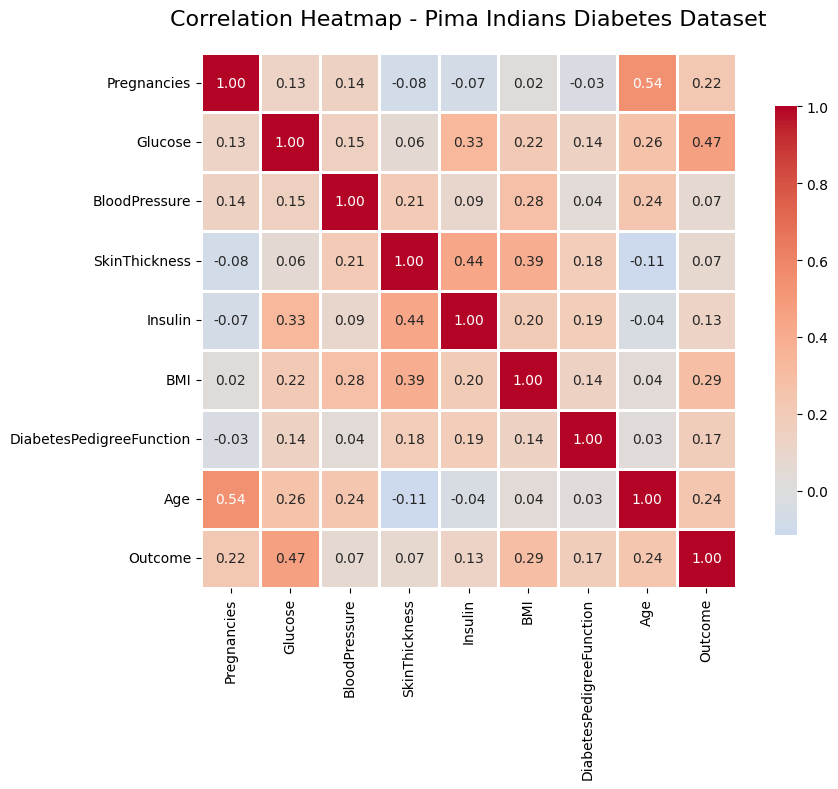

In [3]:
# Create correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=1,  # Add gridlines
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap - Pima Indians Diabetes Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
cols = list(df.columns)
for i, c in enumerate(cols, start=1):
    print(f"{i}. {c}")

cols


1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome


['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [8]:
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness','BMI']
df[columns_with_invalid_zeros] = df[columns_with_invalid_zeros].replace(0, np.nan)

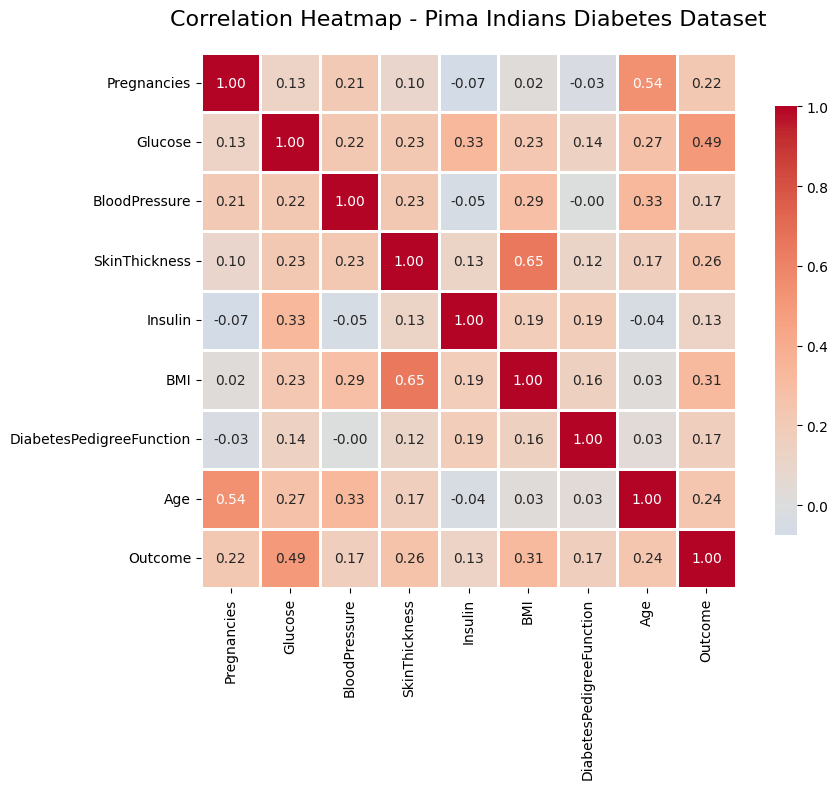

In [9]:
# Create correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=1,  # Add gridlines
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap - Pima Indians Diabetes Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


In [11]:
zero_counts = (df == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [12]:
# Filter rows where Age > 40
age_over_40 = df[df['Age'] > 40]
print(age_over_40)

# To see how many rows match this condition
print(f"Number of rows with Age > 40: {len(age_over_40)}")

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0        0  33.6   
8              2    197.0           70.0           45.0      543  30.5   
9              8    125.0           96.0            NaN        0   NaN   
12            10    139.0           80.0            NaN        0  27.1   
13             1    189.0           60.0           23.0      846  30.1   
..           ...      ...            ...            ...      ...   ...   
757            0    123.0           72.0            NaN        0  36.3   
759            6    190.0           92.0            NaN        0  35.5   
761            9    170.0           74.0           31.0        0  44.0   
763           10    101.0           76.0           48.0      180  32.9   
766            1    126.0           60.0            NaN        0  30.1   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
8                  

In [13]:
age_over_40.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,194.000000,193.000000,189.000000,111.000000,194.000000,192.000000,194.000000,194.000000,194.000000
mean,6.639175,131.740933,78.306878,31.153153,72.613402,33.051042,0.473021,50.273196,0.525773
std,3.619709,32.784575,11.155144,10.980311,129.153441,6.184561,0.326725,8.356847,0.500627
min,0.000000,57.000000,50.000000,7.000000,0.000000,19.600000,0.085000,41.000000,0.000000
25%,5.000000,106.000000,72.000000,25.000000,0.000000,28.775000,0.235500,43.000000,0.000000
50%,7.000000,129.000000,78.000000,31.000000,0.000000,32.900000,0.365500,48.000000,1.000000
75%,9.000000,155.000000,84.000000,36.000000,126.000000,37.125000,0.645250,56.000000,1.000000
max,17.000000,197.000000,114.000000,99.000000,846.000000,47.900000,1.781000,81.000000,1.000000


In [14]:
# Filter rows where Age > 40
age_below_40 = df[df['Age'] < 40]
print(age_below_40)

# To see how many rows match this condition
print(f"Number of rows with Age < 40: {len(age_below_40)}")

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1              1     85.0           66.0           29.0        0  26.6   
2              8    183.0           64.0            NaN        0  23.3   
3              1     89.0           66.0           23.0       94  28.1   
4              0    137.0           40.0           35.0      168  43.1   
5              5    116.0           74.0            NaN        0  25.6   
..           ...      ...            ...            ...      ...   ...   
760            2     88.0           58.0           26.0       16  28.4   
762            9     89.0           62.0            NaN        0  22.5   
764            2    122.0           70.0           27.0        0  36.8   
765            5    121.0           72.0           23.0      112  26.2   
767            1     93.0           70.0           31.0        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
1                       0.351   31        0  
2                  

In [15]:
age_below_40.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,561.000000,557.000000,532.00000,421.000000,561.000000,552.000000,561.000000,561.000000,561.000000
mean,2.823529,117.987433,70.25000,28.501188,82.458111,32.225543,0.473701,27.194296,0.285205
std,2.638157,29.105950,12.18994,10.291611,110.342755,7.152999,0.335539,5.212592,0.451915
min,0.000000,44.000000,24.00000,8.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,97.000000,62.00000,20.000000,0.000000,27.075000,0.247000,23.000000,0.000000
50%,2.000000,113.000000,70.00000,29.000000,52.000000,31.600000,0.375000,26.000000,0.000000
75%,4.000000,133.000000,78.00000,36.000000,128.000000,36.500000,0.619000,31.000000,1.000000
max,14.000000,199.000000,122.00000,63.000000,744.000000,67.100000,2.420000,39.000000,1.000000


In [16]:
df_filled = df.copy()

# Define age groups
age_over_or_equal_40_mask = df_filled['Age'] >= 40
age_40_under_mask = df_filled['Age'] < 40

# Calculate statistics for each age group (excluding NaN values)
# For Age >= 40
glucose_median_over_40 = df_filled.loc[age_over_or_equal_40_mask, 'Glucose'].median()
bp_mean_over_40 = df_filled.loc[age_over_or_equal_40_mask, 'BloodPressure'].mean()

# For Age < 40
glucose_median_40_or_under = df_filled.loc[age_40_under_mask, 'Glucose'].median()
bp_mean_40_or_under = df_filled.loc[age_40_under_mask, 'BloodPressure'].mean()

# Fill NaN values based on age groups
df_filled.loc[(age_over_or_equal_40_mask) & (df_filled['Glucose'].isna()), 'Glucose'] = glucose_median_over_40
df_filled.loc[(age_over_or_equal_40_mask) & (df_filled['BloodPressure'].isna()), 'BloodPressure'] = bp_mean_over_40

df_filled.loc[(age_40_under_mask) & (df_filled['Glucose'].isna()), 'Glucose'] = glucose_median_40_or_under
df_filled.loc[(age_40_under_mask) & (df_filled['BloodPressure'].isna()), 'BloodPressure'] = bp_mean_40_or_under

# Display the statistics used for imputation
print("=== Imputation Values ===")
print(f"Age >= 40:")
print(f"  Glucose median: {glucose_median_over_40:.2f}")
print(f"  BloodPressure mean: {bp_mean_over_40:.2f}")
print(f"\nAge < 40:")
print(f"  Glucose median: {glucose_median_40_or_under:.2f}")
print(f"  BloodPressure mean: {bp_mean_40_or_under:.2f}")

# Check how many values were filled
print("\n=== Number of Values Filled ===")
print(f"Glucose zeros/NaN before: {(df['Glucose'] == 0).sum()}")
print(f"Glucose NaN after: {df_filled['Glucose'].isna().sum()}")
print(f"BloodPressure zeros/NaN before: {(df['BloodPressure'] == 0).sum()}")
print(f"BloodPressure NaN after: {df_filled['BloodPressure'].isna().sum()}")

=== Imputation Values ===
Age >= 40:
  Glucose median: 129.00
  BloodPressure mean: 78.11

Age < 40:
  Glucose median: 113.00
  BloodPressure mean: 70.25

=== Number of Values Filled ===
Glucose zeros/NaN before: 0
Glucose NaN after: 0
BloodPressure zeros/NaN before: 0
BloodPressure NaN after: 0


In [17]:
df_filled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,541.000000,768.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.651042,72.368368,29.153420,79.799479,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.443537,12.114058,10.476982,115.244002,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.000000,0.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,30.500000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
zero_counts = (df_filled == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [19]:
df_filled.isna().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                       0
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [20]:
BMI_zero = df_filled[df_filled['BMI'] == 0]
print(BMI_zero)

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [21]:
BMI_zero

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [22]:
# First replace zeros with NaN (if not already done)
df_filled['BMI'] = df_filled['BMI'].replace(0, np.nan)

# Calculate median BMI (excluding NaN values)
bmi_median = df_filled['BMI'].median()  # pandas automatically excludes NaN

# Fill NaN values with median
df_filled['BMI'] = df_filled['BMI'].fillna(bmi_median)

# Display results
print(f"BMI median value used for imputation: {bmi_median:.2f}")
print(f"Remaining NaN in BMI: {df_filled['BMI'].isna().sum()}")

BMI median value used for imputation: 32.30
Remaining NaN in BMI: 0


In [23]:
df_filled.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [24]:
# Filter by Outcome
no_diabetes = df_filled[df_filled['Outcome'] == 0]
has_diabetes = df_filled[df_filled['Outcome'] == 1]

In [25]:
no_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,500.000000,500.000000,500.000000,361.000000,500.000000,500.000000,500.000000,500.000000,500.0
mean,3.298000,110.658000,70.900657,27.235457,68.792000,30.885600,0.429734,31.190000,0.0
std,3.017185,24.702986,11.941130,10.026491,98.865289,6.504128,0.299085,11.667655,0.0
min,0.000000,44.000000,24.000000,7.000000,0.000000,18.200000,0.078000,21.000000,0.0
25%,1.000000,93.000000,63.500000,19.000000,0.000000,25.750000,0.229750,23.000000,0.0
50%,2.000000,107.500000,70.250000,27.000000,39.000000,30.400000,0.336000,27.000000,0.0
75%,5.000000,125.000000,78.000000,33.000000,105.000000,35.300000,0.561750,37.000000,0.0
max,13.000000,197.000000,122.000000,60.000000,744.000000,57.300000,2.329000,81.000000,0.0


In [26]:
has_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,268.000000,268.000000,268.000000,180.000000,268.000000,268.000000,268.000000,268.000000,268.0
mean,4.865672,142.160448,75.106636,33.000000,100.335821,35.383582,0.550500,37.067164,1.0
std,3.741239,29.553487,11.979738,10.327595,138.689125,6.595603,0.372354,10.968254,0.0
min,0.000000,78.000000,30.000000,7.000000,0.000000,22.900000,0.088000,21.000000,1.0
25%,1.750000,119.000000,68.000000,27.000000,0.000000,30.900000,0.262500,28.000000,1.0
50%,4.000000,140.000000,74.000000,32.000000,0.000000,34.250000,0.449000,36.000000,1.0
75%,8.000000,167.000000,82.000000,39.000000,167.250000,38.775000,0.728000,44.000000,1.0
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.420000,70.000000,1.0


In [27]:
# Drop the specified columns from the features
df_filled = df_filled.drop(columns=['Insulin', 'Pregnancies'])
print("Columns remaining in features:", df_filled.columns.tolist())


Columns remaining in features: ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


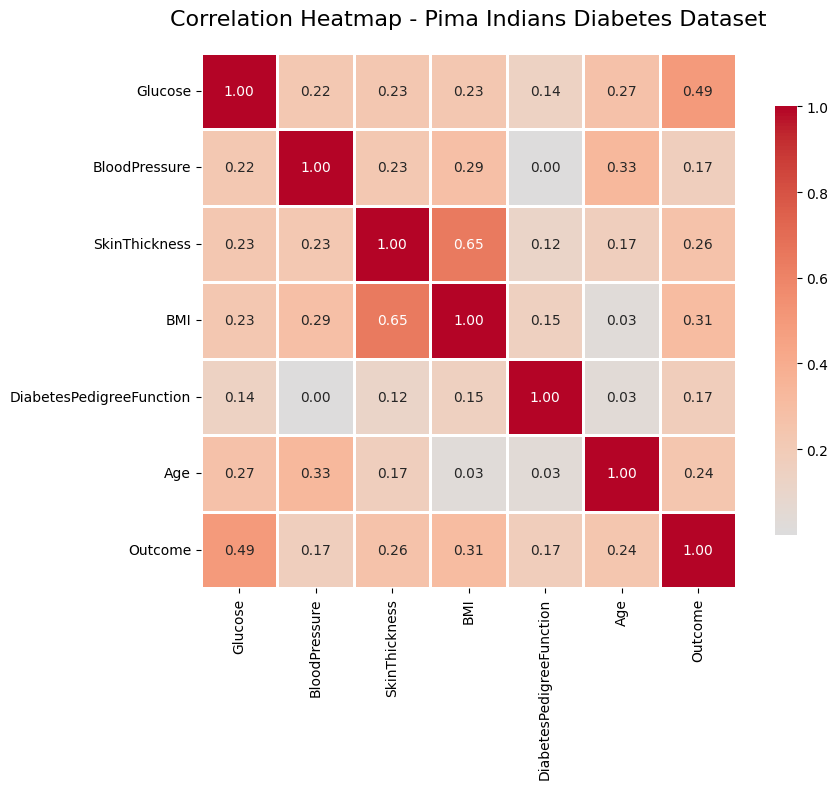

In [28]:
# Create correlation matrix
correlation_matrix = df_filled.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=1,  # Add gridlines
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap - Pima Indians Diabetes Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [29]:
zero_counts = (df_filled == 0).sum()
print(zero_counts)

Glucose                       0
BloodPressure                 0
SkinThickness                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [30]:
# Calculate mean SkinThickness for each outcome group (excluding zeros)
mean_skin_outcome_0 = df_filled.loc[(df_filled['Outcome'] == 0) & (df_filled['SkinThickness'] != 0), 'SkinThickness'].mean()
mean_skin_outcome_1 = df_filled.loc[(df_filled['Outcome'] == 1) & (df_filled['SkinThickness'] != 0), 'SkinThickness'].mean()

# Fill zeros based on outcome
df_filled.loc[(df_filled['Outcome'] == 0) & (df_filled['SkinThickness'] == 0), 'SkinThickness'] = mean_skin_outcome_0
df_filled.loc[(df_filled['Outcome'] == 1) & (df_filled['SkinThickness'] == 0), 'SkinThickness'] = mean_skin_outcome_1

# Display results
print("=== Imputation Values ===")
print(f"Mean SkinThickness for Outcome 0 (No Diabetes): {mean_skin_outcome_0:.2f}")
print(f"Mean SkinThickness for Outcome 1 (Diabetes): {mean_skin_outcome_1:.2f}")

print("\n=== Zeros Filled ===")
print(f"SkinThickness zeros before: {(df['SkinThickness'] == 0).sum()}")
print(f"SkinThickness zeros after: {(df_filled['SkinThickness'] == 0).sum()}")

=== Imputation Values ===
Mean SkinThickness for Outcome 0 (No Diabetes): 27.24
Mean SkinThickness for Outcome 1 (Diabetes): 33.00

=== Zeros Filled ===
SkinThickness zeros before: 0
SkinThickness zeros after: 0


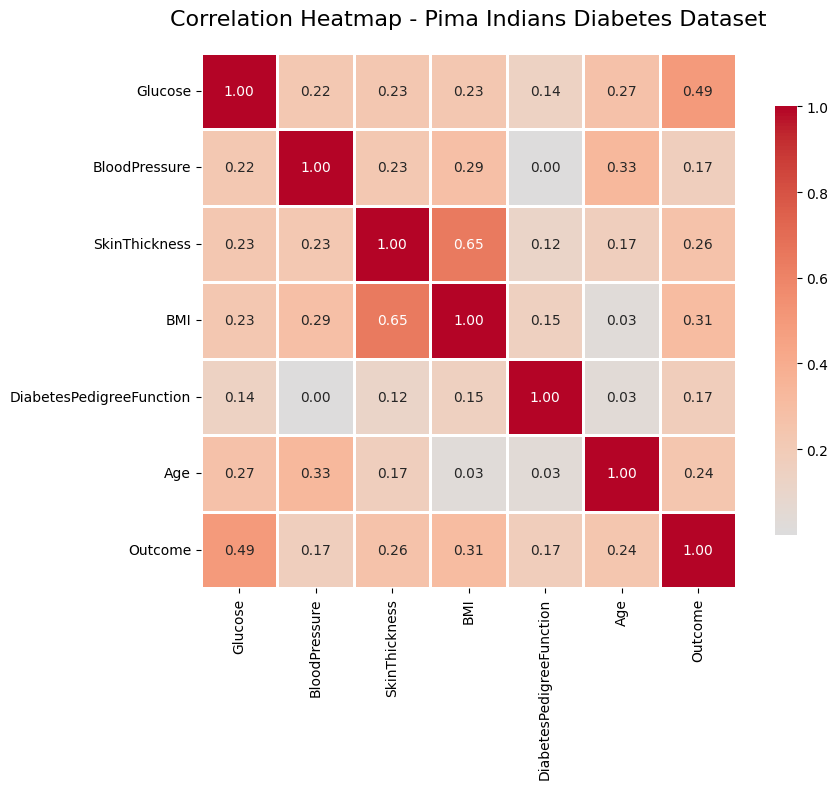

In [31]:
# Create correlation matrix
correlation_matrix = df_filled.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=1,  # Add gridlines
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap - Pima Indians Diabetes Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [32]:
df_filled = df_filled.drop(columns=['BloodPressure','DiabetesPedigreeFunction','Age' ])

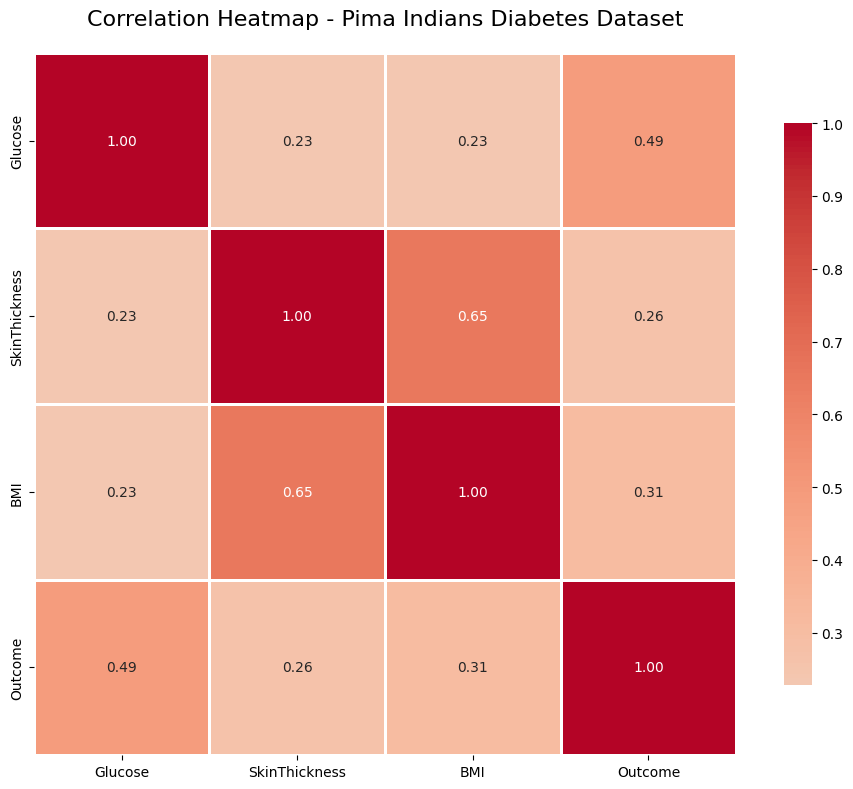

In [33]:
# Create correlation matrix
correlation_matrix = df_filled.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=1,  # Add gridlines
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap - Pima Indians Diabetes Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [34]:
zero_counts = (df_filled == 0).sum()
print(zero_counts)

Glucose            0
SkinThickness      0
BMI                0
Outcome          500
dtype: int64


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming df_filled is your cleaned dataset
# Separate features and target
X = df_filled.drop('Outcome', axis=1)
y = df_filled['Outcome']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.1,          # 20% for test
    stratify=y,             # Stratify based on Outcome
    random_state=42         # For reproducibility
)

# Verify the split
print("=== Dataset Split Summary ===")
print(f"Total samples: {len(df_filled)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(df_filled)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(df_filled)*100:.1f}%)")

# Check outcome distribution
print("\n=== Outcome Distribution ===")
print("Original dataset:")
print(df_filled['Outcome'].value_counts(normalize=True).sort_index())
print(f"  No Diabetes (0): {(df_filled['Outcome']==0).sum()} samples")
print(f"  Diabetes (1): {(df_filled['Outcome']==1).sum()} samples")

print("\nTraining set:")
print(y_train.value_counts(normalize=True).sort_index())
print(f"  No Diabetes (0): {(y_train==0).sum()} samples")
print(f"  Diabetes (1): {(y_train==1).sum()} samples")

print("\nTest set:")
print(y_test.value_counts(normalize=True).sort_index())
print(f"  No Diabetes (0): {(y_test==0).sum()} samples")
print(f"  Diabetes (1): {(y_test==1).sum()} samples")

=== Dataset Split Summary ===
Total samples: 768
Training samples: 691 (90.0%)
Test samples: 77 (10.0%)

=== Outcome Distribution ===
Original dataset:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64
  No Diabetes (0): 500 samples
  Diabetes (1): 268 samples

Training set:
Outcome
0    0.65123
1    0.34877
Name: proportion, dtype: float64
  No Diabetes (0): 450 samples
  Diabetes (1): 241 samples

Test set:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64
  No Diabetes (0): 50 samples
  Diabetes (1): 27 samples


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 



In [37]:
from sklearn.svm import SVC

# Initialize the SVM classifier with a linear kernel
# C is the regularization parameter.
# random_state is used for reproducibility.
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# Train the model
print("\n=== Training the SVM Model ===")
svm_model.fit(X_train_scaled, y_train)
print("Model training complete.")

# The scaler is 'fit' only on the training data to prevent data leakage from the test set.
y_pred = svm_model.predict(X_test_scaled) 



=== Training the SVM Model ===


ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


=== Model Evaluation ===
Accuracy: 0.8312 (83.12%)

--- Confusion Matrix ---
[[44  6]
 [ 7 20]]


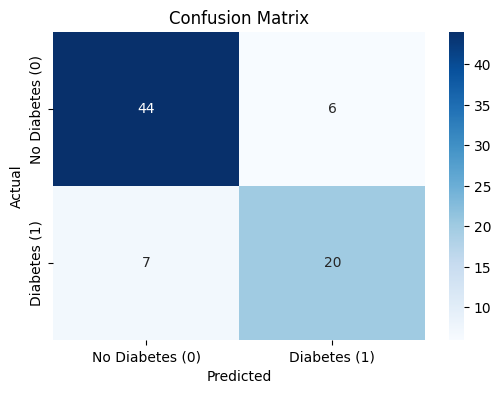


--- Classification Report ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.86      0.88      0.87        50
   Diabetes (1)       0.77      0.74      0.75        27

       accuracy                           0.83        77
      macro avg       0.82      0.81      0.81        77
   weighted avg       0.83      0.83      0.83        77



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Model Evaluation ===")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# For a more visual representation of the confusion matrix:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'], 
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- Classification Report ---
# This report includes precision, recall, and F1-score for each class.
print("\n--- Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)'])
print(report)

In [ ]:
import os, nbformat
from nbconvert import PythonExporter

nb_path = "D:\Private\Python\myenv\pima_indian_Owen_Samuel.ipynb"
py_path = "D:\Private\Python\myenv\pima_indian_Owen_Samuel.py"

nb = nbformat.read(nb_path, as_version=4)
exporter = PythonExporter()
body, resources = exporter.from_notebook_node(nb)

with open(py_path, "w", encoding="utf-8") as f:
    f.write(body)

py_path

'D:\\Private\\Python\\myenv\\pima_indian_Owen_Samuel.py'

In [ ]:
python3 -m ipykernel install --user

SyntaxError: invalid syntax (4042870683.py, line 1)